In [1]:
import pandas as pd 

In [2]:
names = [
    "entropy0.01", "entropy0.0"
]
dfs = [
    pd.read_json(path_or_buf="~/out/fixed/Qwen/Qwen2.5-7B_entropy_0.01_kl_0.001_20250808_130223/metrics.jsonl", lines=True),
    pd.read_json(path_or_buf="~/out/fixed/Qwen/Qwen2.5-7B_entropy_0.0_kl_0.001_20250808_130226/metrics.jsonl", lines=True)
]

In [3]:
dfs[0].columns

Index(['step', 'global_seqlen/min', 'global_seqlen/max',
       'global_seqlen/minmax_diff', 'global_seqlen/balanced_min',
       'global_seqlen/balanced_max', 'global_seqlen/mean',
       'total_seen_samples', 'actor/kl_loss', 'actor/kl_coef', 'actor/entropy',
       'actor/pg_loss', 'actor/pg_clipfrac', 'actor/ppo_kl', 'actor/grad_norm',
       'perf/estimated_flops_per_update', 'perf/mfu/actor',
       'perf/max_memory_allocated_gb', 'perf/max_memory_reserved_gb',
       'perf/cpu_memory_used_gb', 'actor/lr', 'critic/score/mean',
       'critic/score/max', 'critic/score/min', 'critic/rewards/mean',
       'critic/rewards/max', 'critic/rewards/min', 'critic/advantages/mean',
       'critic/advantages/max', 'critic/advantages/min', 'critic/returns/mean',
       'critic/returns/max', 'critic/returns/min', 'response_length/mean',
       'response_length/max', 'response_length/min',
       'response_length/clip_ratio', 'prompt_length/mean', 'prompt_length/max',
       'prompt_length/min'

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_(name : str, window_size=10):
    window = np.ones(shape=(window_size,))
    for label, df in zip(names, dfs):
        ys = df[name].to_numpy()
        ys = np.convolve(ys, window)
        ys = ys[~np.isnan(ys)]

        plt.plot(ys, label=label)
        plt.title(f"Metric: {name}, sliding-window size: {window_size}")
    plt.legend()
    plt.show()

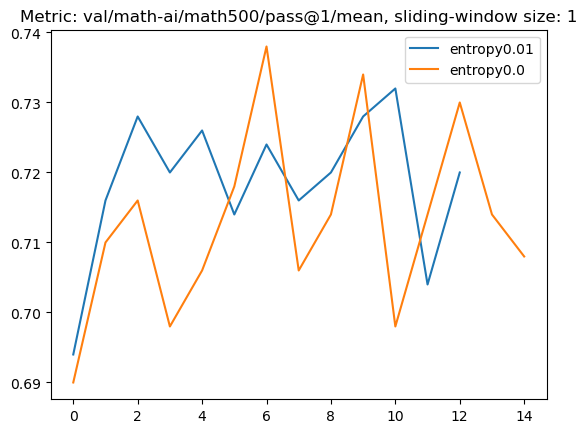

In [12]:
plot_('val/math-ai/math500/pass@1/mean', window_size=1)

In [ ]:
dfs[2]['val/math-ai/math500/pass@1/mean@1'].to_numpy()

AttributeError: 'Series' object has no attribute 'filter_nan'